# Light Curve Plotter
Reads ECSV light curve files (comma- or space-separated) and plots detections vs. upper limits.
Multiple instruments and/or energy ranges are automatically assigned distinct colours and markers.

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.table import Table
from astropy.time import Time
from datetime import timedelta

In [5]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Change here to your path and file
path_user = "/Users/stefano/Documenti/work/CTAO/project_Doro/git_repository/"
path_git = "magic_dl5_dataportal/ecsv/"
path_project = "inprep/2025g_GRB_UL/" #   2022e_maxiJ1820
ecsv_name = "magic_2025g_fig4_130701A_lc.ecsv"
ECSV_FILE = path_user+path_git+path_project+ecsv_name
# ───────────────────────────────────────────────────────────────────────────────

In [6]:
# ── Utilities ──────────────────────────────────────────────────────────────────

def detect_delimiter(filepath):
    """Return the delimiter declared in the ECSV header, or ' ' if absent."""
    with open(filepath, "r") as fh:
        for line in fh:
            if not line.startswith("#"):
                break
            m = re.search(r"delimiter:\s*['\"]?(.)['\"]", line)
            if m:
                return m.group(1)
    return " "


def load_ecsv(filepath):
    """Load an ECSV file regardless of delimiter and return an Astropy Table."""
    delim = detect_delimiter(filepath)
    return Table.read(filepath, format="ascii.ecsv", delimiter=delim)


def is_upper_limit(dataformat_value):
    """True when the dataformat cell flags an upper limit (UL or 'upper limit …')."""
    if dataformat_value is None:
        return False
    val = str(dataformat_value)
    return bool(
        re.search(r"upper\s+limit", val, re.IGNORECASE)
        or re.search(r"\bUL\b", val, re.IGNORECASE)
    )


def mjd_to_datetime(mjd_array):
    """Convert MJD float array to Python datetime objects for matplotlib."""
    return Time(np.asarray(mjd_array, dtype=float), format="mjd").to_datetime()


def col_float(table, name, mask):
    """Return a float numpy array for column *name* filtered by *mask*."""
    return np.array(table[name][mask], dtype=float)


def _unit_str(table, col):
    """Return the unit string of a column, or '' if absent/null."""
    try:
        u = str(table[col].unit)
        return u if u not in ("", "None", "nan") else ""
    except Exception:
        return ""


def norm_energy(val):
    """Normalise an energy value to float; return np.nan if missing/null."""
    try:
        f = float(val)
        return f if np.isfinite(f) else np.nan
    except (TypeError, ValueError):
        return np.nan


def format_energy(val, unit):
    """Pretty-print an energy bound; return '' for NaN/None."""
    try:
        f = float(val)
        if np.isfinite(f):
            return f"{f:g}\u2009{unit}" if unit else f"{f:g}"
    except (TypeError, ValueError):
        pass
    return ""


def make_group_label(instrument, eth_lo, eth_up, eth_lo_unit, eth_up_unit, single_group):
    """
    Build a legend label for a (instrument, eth_lo, eth_up) group.
    When there is only one group the label is just the instrument name.
    """
    if single_group:
        return str(instrument)
    lo = format_energy(eth_lo, eth_lo_unit)
    up = format_energy(eth_up, eth_up_unit)
    if lo and up:
        energy_str = f"{lo}\u2013{up}"
    elif lo:
        energy_str = f">{lo}"
    elif up:
        energy_str = f"<{up}"
    else:
        energy_str = ""
    return f"{instrument} ({energy_str})" if energy_str else str(instrument)

In [7]:
# ── Load data ──────────────────────────────────────────────────────────────────
tbl = load_ecsv(ECSV_FILE)
print(f"Loaded {len(tbl)} rows  |  columns: {tbl.colnames}")
tbl[:5]

Loaded 8 rows  |  columns: ['srcname', 't', 't_wlo', 't_wup', 't_exp', 'flux', 'flux_elo', 'flux_eup', 'eth_lo', 'eth_up', 'instrument', 'dataformat', 'comments']


srcname,t,t_wlo,t_wup,t_exp,flux,flux_elo,flux_eup,eth_lo,eth_up,instrument,dataformat,comments
latex,mjd,d,d,h,erg/cm^2^/s,erg/cm^2^/s,erg/cm^2^/s,TeV,TeV,latex,latex,latex
str7,float32,float32,float32,float32,float32,float32,float32,float32,float32,str5,str2,str47
130701A,56474.184,0.002332,0.002332,0.1119,4.45e-10,0.0,0.0,100.0,696.0,MAGIC,UL,EBL=Franceschini & Rodighiero (2018); Gamma=1.6
130701A,56474.184,0.002332,0.002332,0.1119,2.7e-10,0.0,0.0,100.0,696.0,MAGIC,UL,EBL=Franceschini & Rodighiero (2018); Gamma=2.2
130701A,56474.184,0.002332,0.002332,0.1119,1.14e-09,0.0,0.0,100.0,696.0,MAGIC,UL,EBL=Gilmore et al. (2012); Gamma=1.6
130701A,56474.184,0.002332,0.002332,0.1119,6.57e-10,0.0,0.0,100.0,696.0,MAGIC,UL,EBL=Gilmore et al. (2012); Gamma=2.2
130701A,56474.19,0.011198,0.011198,0.5375,1.76e-10,0.0,0.0,100.0,696.0,MAGIC,UL,EBL=Franceschini & Rodighiero (2018); Gamma=1.6


In [8]:
# ── Global metadata ────────────────────────────────────────────────────────────
meta = tbl.meta
source_name = (
    meta.get("Source")
    or (str(tbl["srcname"][0]) if "srcname" in tbl.colnames else "Unknown source")
)

eth_lo_unit = _unit_str(tbl, "eth_lo")
eth_up_unit = _unit_str(tbl, "eth_up")
flux_unit   = _unit_str(tbl, "flux")

print(f"Source: {source_name}")
print(f"Flux unit: {flux_unit}")

Source: 130701A
Flux unit: erg/cm^2^/s


In [9]:
# ── Build dataset groups ───────────────────────────────────────────────────────
# A 'group' is a unique (instrument, eth_lo, eth_up) triplet.
# NaN energy bounds compare equal across rows via their string representation.

instruments_col = [str(v) for v in tbl["instrument"]]
eth_lo_col      = [norm_energy(v) for v in tbl["eth_lo"]]
eth_up_col      = [norm_energy(v) for v in tbl["eth_up"]]


def _key(i):
    lo = eth_lo_col[i]
    up = eth_up_col[i]
    return (
        instruments_col[i],
        f"{lo:g}" if np.isfinite(lo) else "nan",
        f"{up:g}" if np.isfinite(up) else "nan",
    )


# Collect groups in insertion order (preserves the order they appear in the file)
seen = {}
for i in range(len(tbl)):
    k = _key(i)
    if k not in seen:
        seen[k] = (instruments_col[i], eth_lo_col[i], eth_up_col[i])

groups = list(seen.values())   # [(instrument, eth_lo, eth_up), ...]
single_group = len(groups) == 1

print(f"Found {len(groups)} dataset group(s):")
for g in groups:
    print(f"  instrument={g[0]}  eth_lo={g[1]}  eth_up={g[2]}")

Found 1 dataset group(s):
  instrument=MAGIC  eth_lo=100.0  eth_up=696.0


In [10]:
# ── Visual style palette ───────────────────────────────────────────────────────
# Colours and detection markers cycle independently so many groups stay distinct.
# Upper limits always use a downward triangle (▼) in the same colour as the group.

COLORS = [
    "#1f77b4",  # blue
    "#d62728",  # red
    "#2ca02c",  # green
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#17becf",  # cyan
    "#bcbd22",  # yellow-green
    "#ff7f0e",  # orange
]
DET_MARKERS = ["o", "s", "^", "D", "P", "X", "*", "h", "+"]


def style_for(group_index):
    """Return (color, detection_marker) for a given group index."""
    idx = group_index % len(COLORS)
    return COLORS[idx], DET_MARKERS[idx % len(DET_MARKERS)]

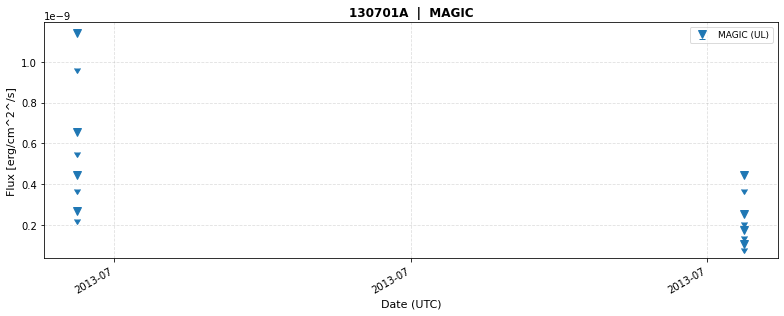

In [11]:
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

ul_mask_global = np.array([is_upper_limit(v) for v in tbl["dataformat"]])

for g_idx, (instr, lo, up) in enumerate(groups):
    color, det_mk = style_for(g_idx)

    # Build a boolean mask for all rows belonging to this group
    lo_s = f"{lo:g}" if np.isfinite(lo) else "nan"
    up_s = f"{up:g}" if np.isfinite(up) else "nan"
    group_mask = np.array([_key(i) == (instr, lo_s, up_s) for i in range(len(tbl))])

    det_mask = group_mask & ~ul_mask_global
    ul_mask  = group_mask &  ul_mask_global

    label_base = make_group_label(instr, lo, up, eth_lo_unit, eth_up_unit, single_group)

    # ── Detections ────────────────────────────────────────────────────────────
    if det_mask.any():
        t_det   = mjd_to_datetime(col_float(tbl, "t", det_mask))
        f_det   = col_float(tbl, "flux",     det_mask)
# This works when the flux_elo and flux_eup values are the lower and upper boundaries, rather than the errors
#        elo_det = np.abs(f_det - col_float(tbl, "flux_elo", det_mask))
#        eup_det = np.abs(col_float(tbl, "flux_eup", det_mask) - f_det)
# This works when the flux_elo and flux_eup values are the errors
        elo_det = np.abs(col_float(tbl, "flux_elo", det_mask))
        eup_det = np.abs(col_float(tbl, "flux_eup", det_mask))

        xerr = None
        if "t_wlo" in tbl.colnames and "t_wup" in tbl.colnames:
            xerr = (
                [timedelta(days=float(d)) for d in col_float(tbl, "t_wlo", det_mask)],
                [timedelta(days=float(d)) for d in col_float(tbl, "t_wup", det_mask)],
            )

        ax.errorbar(
            t_det, f_det,
            yerr=[elo_det, eup_det],
            xerr=xerr,
            fmt=det_mk,
            color=color,
            markersize=5,
            linewidth=0.8,
            capsize=3,
            label=label_base,
            zorder=3,
        )

    # ── Upper limits ──────────────────────────────────────────────────────────
    if ul_mask.any():
        t_ul = mjd_to_datetime(col_float(tbl, "t",    ul_mask))
        f_ul = col_float(tbl, "flux", ul_mask)

        ax.errorbar(
            t_ul, f_ul,
            yerr=0.15 * f_ul,   # cosmetic arrow length
            fmt="v",
            color=color,
            markersize=8,
            linewidth=0,
            capsize=0,
            uplims=True,
            label=f"{label_base} (UL)",
            zorder=3,
        )

# ── Axes cosmetics ─────────────────────────────────────────────────────────────
ax.set_xlabel("Date (UTC)", fontsize=11)
ax.set_ylabel(f"Flux [{flux_unit}]" if flux_unit else "Flux", fontsize=11)

# Title: source name + ordered-unique list of all instruments
all_instruments = ", ".join(dict.fromkeys(g[0] for g in groups))
ax.set_title(
    f"{source_name}  |  {all_instruments}",
    fontsize=12, fontweight="bold",
)

fig.autofmt_xdate(rotation=30, ha="right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.legend(fontsize=9, framealpha=0.7)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("lightcurve.png", dpi=150, bbox_inches="tight")
plt.show()
# If needed, uncomment the following lines to create a png of the light curve
#plt.savefig("lightcurve.png", dpi=150, bbox_inches="tight")
#plt.show()
#print("Figure saved as lightcurve.png")